# 🧮 Week 2 — Day 3: Linear Algebra for ML

**BinX Tech — AI & Machine Learning Internship Program**

![status](https://img.shields.io/badge/status-in--progress-yellow)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-NumPy%20%7C%20Matplotlib-orange)
![topic](https://img.shields.io/badge/topic-Vectors%20%7C%20Matrices%20%7C%20Dot%20Product-9146FF)

---

| | |
|---|---|
| **Day** | Day 3 of 5 |
| **Duration** | 8 hours |
| **Tools** | NumPy • Matplotlib • Jupyter Notebook |
| **Prerequisite** | Day 1 & Day 2 completed |

---

## 🎯 Learning Objectives

- Represent data samples as vectors and datasets as matrices.
- Compute a dot product and explain why it is central to model prediction.
- Perform matrix multiplication and reason about resulting shapes.

---

## 💡 Why This Matters

Every dataset in ML is a matrix: rows are samples, columns are features. Every model's parameters
are vectors or matrices, and training is a sequence of matrix operations. Understanding these
objects is understanding what a model is doing internally — not just calling `.fit()` on a black
box.

---


## 🔧 Step 0 — Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📍 Step 1 — Vectors: One Sample's Features

A **vector** is an ordered list of numbers — in ML, it usually represents one data sample's
features. A customer described by `[age, income, tenure]` is a 3-dimensional vector.


In [2]:
customer = np.array([25, 50000, 3])  # [age, income (scaled), tenure]
print("Customer vector:", customer)
print("Shape:", customer.shape)


Customer vector: [   25 50000     3]
Shape: (3,)


### 📊 Visualizing a Vector in 2D

To build intuition, let's visualize a simple 2D vector as an arrow from the origin — this is
exactly what a vector represents geometrically: a direction and magnitude in space.


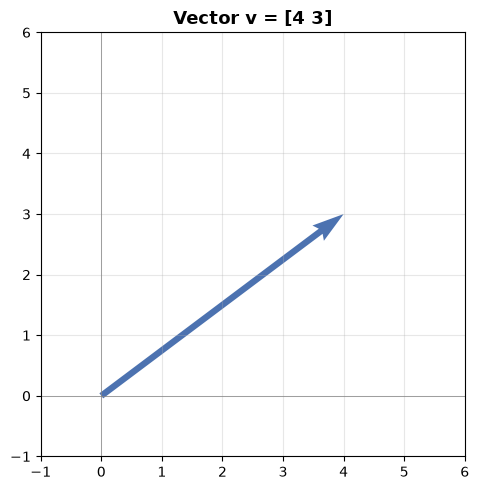

In [3]:
v = np.array([4, 3])

plt.figure(figsize=(5, 5))
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
           color="#4C72B0", width=0.015)
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(alpha=0.3)
plt.title(f"Vector v = {v}", fontsize=13, fontweight="bold")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — describe the direction and length of the arrow. How does it
relate to the numbers [4, 3]?)*

---

## 🗂️ Step 2 — Matrices: A Full Dataset

A **matrix** is a 2D grid of numbers — a full dataset, where each row is a sample vector and each
column is a feature. Its shape is `(rows, columns) = (samples, features)`.


In [4]:
X = np.array([[25, 50000, 3],
              [40, 80000, 10],
              [33, 62000, 5]])

print("Dataset matrix X:")
print(X)
print("\nShape:", X.shape, "→", X.shape[0], "samples,", X.shape[1], "features")


Dataset matrix X:
[[   25 50000     3]
 [   40 80000    10]
 [   33 62000     5]]

Shape: (3, 3) → 3 samples, 3 features


### 🎨 Visualizing a Matrix as a Heatmap

A heatmap makes it easy to see the scale and pattern of values across an entire matrix at once.


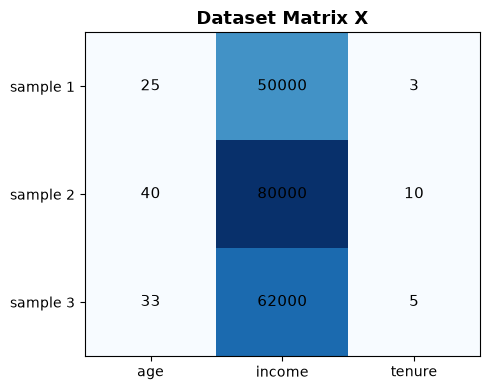

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(X, cmap="Blues", aspect="auto")

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        ax.text(j, i, X[i, j], ha="center", va="center", color="black", fontsize=11)

ax.set_xticks(range(X.shape[1]))
ax.set_xticklabels(["age", "income", "tenure"])
ax.set_yticks(range(X.shape[0]))
ax.set_yticklabels([f"sample {i+1}" for i in range(X.shape[0])])
ax.set_title("Dataset Matrix X", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — how does the heatmap make the difference in scale between
`income` and the other columns visually obvious? Why might that matter before feeding this into a
model?)*

---

## ⚡ Step 3 — The Dot Product

The dot product multiplies two vectors element-by-element and sums the result, producing a single
number. This is **the single most important operation in ML**: a linear model's prediction is
exactly the dot product of a feature vector and a weight vector, plus a bias.


In [6]:
features = np.array([25, 50000, 3])
weights  = np.array([0.1, 0.0002, 1.5])

prediction = np.dot(features, weights)

print("features:", features)
print("weights: ", weights)
print("\nprediction = (25×0.1) + (50000×0.0002) + (3×1.5)")
print("prediction =", prediction)


features: [   25 50000     3]
weights:  [0.1 0.  1.5]

prediction = (25×0.1) + (50000×0.0002) + (3×1.5)
prediction = 17.0


### 📝 Interpretation

*(Fill this in — this is precisely how linear and logistic regression compute their output:
`prediction = dot(features, weights) + bias`. In your own words, why does this single number
represent a "prediction"?)*

---

## 🔗 Step 4 — Matrix Multiplication

Matrix multiplication applies the dot product across whole matrices at once, letting a model make
predictions for **every sample in a dataset in a single operation**.

**The golden rule:** an `(m × n)` matrix times an `(n × p)` matrix gives an `(m × p)` matrix — the
inner dimensions must match.


In [7]:
X = np.array([[25, 50000, 3],
              [40, 80000, 10]])          # shape (2, 3)
w = np.array([0.1, 0.0002, 1.5])          # shape (3,)

predictions = X @ w                        # shape (2,): one prediction per sample

print("X shape:", X.shape)
print("w shape:", w.shape)
print("\nPredictions for all samples at once:", predictions)


X shape: (2, 3)
w shape: (3,)

Predictions for all samples at once: [17. 35.]


### 🧩 Step-by-Step Breakdown

Let's manually verify the first prediction to confirm what matrix multiplication is really doing
under the hood.


In [8]:
manual_pred_sample1 = (X[0, 0]*w[0]) + (X[0, 1]*w[1]) + (X[0, 2]*w[2])
print("Manual calculation for sample 1:", manual_pred_sample1)
print("NumPy result for sample 1:      ", predictions[0])
print("Match:", np.isclose(manual_pred_sample1, predictions[0]))


Manual calculation for sample 1: 17.0
NumPy result for sample 1:       17.0
Match: True


### 📝 Interpretation

*(Fill this in — confirm the manual and NumPy results match. Why is this useful — being able to
predict for many samples in one operation instead of a loop?)*

---

## 💥 Step 5 — Deliberately Breaking It: The Shape Mismatch Error

Shape mismatches are the most common error in ML code. Let's create one on purpose, read the
error message, and understand exactly what it's telling us.


In [11]:
bad_weights = np.array([0.1, 0.0002])

try:
    X @ bad_weights
except ValueError as e:
    print("Error caught as expected:")
    print(e)

Error caught as expected:
matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)


### 📝 Interpretation

*(Fill this in — explain in your own words why this error occurred, referencing the shapes of `X`
and `bad_weights`. How would you fix it?)*

---

## ✅ Step 6 — Key Takeaways

*(Write 3–5 sentences summarizing what this notebook demonstrated about vectors, matrices, the dot
product, and matrix multiplication — and how they connect to how ML models actually predict.)*

- ...
- ...
- ...

---

## 📚 Resources

| Resource | Type | Focus |
|---|---|---|
| [3Blue1Brown — Essence of Linear Algebra](https://www.3blue1brown.com/topics/linear-algebra) | Video Series | Visual, geometric intuition for vectors, matrices, and dot products |
| [Khan Academy — Vectors and Matrices](https://www.khanacademy.org/math/algebra-home/alg-matrices) | Course / Video | Core operations and rules |

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 2, Day 3 — Linear Algebra for ML

---

## 🔗 Next Step

Proceed to **Day 4 — EDA Part 1: Distributions & Outliers**
